In [103]:
import numpy as np


In [2]:
import pandas as pd

In [3]:
delivery=pd.read_csv("deliveries.csv")
match=pd.read_csv("matches.csv")

In [4]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
match.shape

(756, 18)

In [6]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [7]:
delivery.shape

(179078, 21)

In [8]:
total_scoredf=delivery.groupby(["match_id","inning"]).sum()["total_runs"].reset_index()

In [9]:
total_scoredf=total_scoredf[total_scoredf["inning"]==1]

In [10]:
match_df=match.merge(total_scoredf[["match_id","total_runs"]],left_on="id",right_on="match_id")

In [11]:
match_df["team1"].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

In [ ]:
teams=[
    "Sunrisers Hyderabad",
    "Mumbai Indians",
    "Royal Challengers Bangalore",
    "Kolkata Knight Riders",
    "Punjab Kings",
    "Chennai Super Kings",
    "Rajasthan Royals",
    "Delhi Capitals",
    "Gujrat Titans",
    "Lucknow Super Gaints"
    ]

In [13]:
match_df["team1"]=match_df["team1"].str.replace("Delhi Daredevils","Delhi Capitals")
match_df["team2"]=match_df["team2"].str.replace("Delhi Daredevils","Delhi Capitals")

In [14]:
match_df["team1"]=match_df["team1"].str.replace("Rising Pune Supergiant","Lucknow Super Gaints")
match_df["team2"]=match_df["team2"].str.replace("Rising Pune Supergiant","Lucknow Super Gaints")

In [15]:
match_df["team1"]=match_df["team1"].str.replace("Kings XI Punjab","Punjab Kings")
match_df["team2"]=match_df["team2"].str.replace("Kings XI Punjab","Punjab Kings")

In [16]:
match_df["team1"]=match_df["team1"].str.replace("Deccan Chargers","Sunrisers Hyderabad")
match_df["team2"]=match_df["team2"].str.replace("Deccan Chargers","Sunrisers Hyderabad")

In [87]:
match_df["winner"].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Mumbai Indians',
       'Delhi Daredevils', 'Gujarat Lions', 'Chennai Super Kings',
       'Rajasthan Royals', 'Deccan Chargers', nan, 'Delhi Capitals'],
      dtype=object)

In [ ]:
match_df["team1"]=match_df["team1"].str.replace("Gujarat Lions","Gujrat Titans")
match_df["team2"]=match_df["team2"].str.replace("Gujarat Lions","Gujrat Titans")

In [19]:
match_df=match_df[match_df["team1"].isin(teams)]
match_df=match_df[match_df["team2"].isin(teams)]

In [20]:
match_df["team1"]=match_df["team1"].str.replace("Lucknow Super Gaintss","Lucknow Super Gaints")
match_df["team2"]=match_df["team2"].str.replace("Lucknow Super Gaintss","Lucknow Super Gaints")

In [21]:
match_df.shape

(683, 20)

In [22]:
match_df=match_df[match_df["dl_applied"]==0]

In [23]:
match_df=match_df[["match_id","city","winner","total_runs"]]

In [24]:
match_df

,match_id,city,winner,total_runs
0,1,Hyderabad,Sunrisers Hyderabad,207
1,2,Pune,Rising Pune Supergiant,184
2,3,Rajkot,Kolkata Knight Riders,183
3,4,Indore,Kings XI Punjab,163
4,5,Bangalore,Royal Challengers Bangalore,157
...,...,...,...,...
751,11347,Mumbai,Mumbai Indians,143
752,11412,Chennai,Mumbai Indians,136
753,11413,Visakhapatnam,Delhi Capitals,171
754,11414,Visakhapatnam,Chennai Super Kings,155


In [25]:
delivery_df=match_df.merge(delivery,on="match_id")

In [26]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
0,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,Hyderabad,Sunrisers Hyderabad,207,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,0,1,0,1,NaN,NaN,NaN
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,0,2,0,2,NaN,NaN,NaN
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [27]:
delivery_df=delivery_df[delivery_df["inning"]==2]

In [28]:
delivery_df.shape

(77212, 24)

In [29]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,0,1,0,1,NaN,NaN,NaN
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,0,NaN,NaN,NaN
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,0,2,0,2,NaN,NaN,NaN
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,0,1,0,1,NaN,NaN,NaN
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,0,2,0,2,NaN,NaN,NaN
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [30]:
delivery_df['current_score'] = (
    delivery_df.groupby('match_id')['total_runs_y'].cumsum()
)

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/3024043727.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['current_score'] = (


In [31]:
delivery_df['total_runs_y'].dtype

dtype('int64')

In [32]:
delivery_df['match_id'].dtype

dtype('int64')

In [33]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,0,0,1,0,1,NaN,NaN,NaN,1
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,0,0,NaN,NaN,NaN,1
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,0,0,NaN,NaN,NaN,1
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,0,0,2,0,2,NaN,NaN,NaN,3
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,0,0,4,0,4,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,1,0,1,NaN,NaN,NaN,152
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,2,0,2,NaN,NaN,NaN,154
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,1,0,1,SR Watson,run out,KH Pandya,155
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,2,0,2,NaN,NaN,NaN,157


In [34]:
delivery_df["runs_left"]= delivery_df["total_runs_x"]-delivery_df["current_score"]+1

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/2613975185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["runs_left"]= delivery_df["total_runs_x"]-delivery_df["current_score"]+1


In [35]:
delivery_df.tail(110)

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left
159442,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,3,3,SR Watson,...,0,0,0,0,0,NaN,NaN,NaN,13,140
159443,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,3,4,SR Watson,...,0,0,0,0,0,NaN,NaN,NaN,13,140
159444,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,3,5,SR Watson,...,0,0,1,0,1,NaN,NaN,NaN,14,139
159445,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,3,6,F du Plessis,...,0,0,5,0,5,NaN,NaN,NaN,19,134
159446,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,4,1,F du Plessis,...,0,0,0,0,0,NaN,NaN,NaN,19,134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,1,0,1,NaN,NaN,NaN,152,1
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,2,0,2,NaN,NaN,NaN,154,-1
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,1,0,1,SR Watson,run out,KH Pandya,155,-2
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,2,0,2,NaN,NaN,NaN,157,-4


In [36]:
delivery_df["balls_left"]=126- (delivery_df["over"]*6 +delivery_df["ball"])

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/3417702291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["balls_left"]=126- (delivery_df["over"]*6 +delivery_df["ball"])


In [37]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,1,0,1,NaN,NaN,NaN,1,207,119
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,207,118
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,NaN,NaN,NaN,1,207,117
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,2,0,2,NaN,NaN,NaN,3,205,116
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,4,0,4,NaN,NaN,NaN,7,201,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,1,0,1,NaN,NaN,NaN,152,1,4
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,2,0,2,NaN,NaN,NaN,154,-1,3
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,1,0,1,SR Watson,run out,KH Pandya,155,-2,2
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,2,0,2,NaN,NaN,NaN,157,-4,1


In [38]:
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].fillna("0")


/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/1496351099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["player_dismissed"]=delivery_df["player_dismissed"].fillna("0")


In [39]:
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].apply(lambda x:x if x == "0" else "1")


/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/2199544330.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["player_dismissed"]=delivery_df["player_dismissed"].apply(lambda x:x if x == "0" else "1")


In [40]:
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].astype("int")


/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/946517723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["player_dismissed"]=delivery_df["player_dismissed"].astype("int")


In [41]:
wickets=delivery_df.groupby("match_id")["player_dismissed"].cumsum().values
delivery_df["wickets_left"]=10-wickets

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/3014749719.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["wickets_left"]=10-wickets


In [42]:
delivery_df.head(125)

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,1,0,1,0,NaN,NaN,1,207,119,10
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,0,0,0,NaN,NaN,1,207,118,10
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,0,0,0,NaN,NaN,1,207,117,10
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,2,0,2,0,NaN,NaN,3,205,116,10
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,4,0,4,0,NaN,NaN,7,201,115,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,YS Chahal,...,1,0,1,0,NaN,NaN,166,42,4,1
246,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,A Choudhary,...,6,0,6,0,NaN,NaN,172,36,3,1
247,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,A Choudhary,...,0,0,0,1,run out,CJ Jordan (sub),172,36,2,0
373,2,Pune,Rising Pune Supergiant,184,2,Rising Pune Supergiant,Mumbai Indians,1,1,AM Rahane,...,1,0,1,0,NaN,NaN,1,184,119,10


In [43]:
delivery_df["rr"]=(
        (delivery_df["runs_left"]*6)/(
            delivery_df["balls_left"]
    )).round(2)

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/1982406098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["rr"]=(


In [44]:
delivery_df["curr"]=(
        delivery_df["current_score"]/(
            (delivery_df["over"]-1)+delivery_df["ball"]/6)
    ).round(2)

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/2394272188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["curr"]=(


In [45]:
def result(row):
    return 1 if row["batting_team"]==row["winner"] else 0

In [46]:
delivery_df["result"]=delivery_df.apply(result,axis=1)

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/2373766016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["result"]=delivery_df.apply(result,axis=1)


In [47]:
delivery_df.shape

(77212, 31)

In [48]:
final_df=delivery_df[["batting_team","bowling_team","city","runs_left","balls_left","wickets_left","total_runs_x","curr","rr","result"]]

In [49]:
final_df=final_df.sample(final_df.shape[0])

In [50]:
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,total_runs_x,curr,rr,result
124974,Mumbai Indians,Kolkata Knight Riders,Mumbai,32,23,6,174,8.85,8.35,1
125394,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,143,79,9,194,7.61,10.86,0
159446,Chennai Super Kings,Mumbai Indians,Hyderabad,134,101,10,152,6.00,7.96,0
62390,Delhi Daredevils,Chennai Super Kings,Chennai,39,9,5,176,7.46,26.00,0
24173,Mumbai Indians,Kings XI Punjab,Mumbai,89,53,8,189,9.04,10.08,0
...,...,...,...,...,...,...,...,...,...,...
115077,Chennai Super Kings,Sunrisers Hyderabad,Hyderabad,140,86,8,192,9.35,9.77,0
28198,Chennai Super Kings,Delhi Daredevils,Durban,100,72,9,189,11.25,8.33,0
48886,Mumbai Indians,Chennai Super Kings,Chennai,145,106,10,165,9.00,8.21,0
131908,Kings XI Punjab,Delhi Daredevils,Mohali,52,42,7,172,9.31,7.43,1


In [51]:
final_df=final_df[final_df["balls_left"]!=0]

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]

In [54]:
y

124974    1
125394    0
159446    0
62390     0
24173     0
         ..
115077    0
28198     0
48886     0
131908    1
60631     1
Name: result, Length: 76956, dtype: int64

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=1
)

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [69]:
trf= ColumnTransformer([
    ('trf',OneHotEncoder(sparse_output=False,drop="first"),["batting_team","bowling_team","city"])
]
,remainder="passthrough")



In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [59]:
from sklearn.pipeline import Pipeline

In [70]:
pipe= Pipeline(
    steps=[
        ("step1",trf),
        ("step2",LogisticRegression(solver="liblinear"))
    ]
)


In [78]:
pipe2= Pipeline(
    steps=[
        ("step1",trf),
        ("step2",RandomForestClassifier())
    ]
)

In [71]:
final_df.dropna(inplace=True)

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_76340/2709626079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.dropna(inplace=True)


In [72]:
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,total_runs_x,curr,rr,result
124974,Mumbai Indians,Kolkata Knight Riders,Mumbai,32,23,6,174,8.85,8.35,1
125394,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,143,79,9,194,7.61,10.86,0
159446,Chennai Super Kings,Mumbai Indians,Hyderabad,134,101,10,152,6.00,7.96,0
62390,Delhi Daredevils,Chennai Super Kings,Chennai,39,9,5,176,7.46,26.00,0
24173,Mumbai Indians,Kings XI Punjab,Mumbai,89,53,8,189,9.04,10.08,0
...,...,...,...,...,...,...,...,...,...,...
115077,Chennai Super Kings,Sunrisers Hyderabad,Hyderabad,140,86,8,192,9.35,9.77,0
28198,Chennai Super Kings,Delhi Daredevils,Durban,100,72,9,189,11.25,8.33,0
48886,Mumbai Indians,Chennai Super Kings,Chennai,145,106,10,165,9.00,8.21,0
131908,Kings XI Punjab,Delhi Daredevils,Mohali,52,42,7,172,9.31,7.43,1


final_df.dropna(inplace=True)

In [73]:
pipe.fit(X_train,y_train)

/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [79]:
pipe2.fit(X_train,y_train)

/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', RandomForestClassifier())])

In [81]:
y_pred=pipe.predict(X_test)

/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [80]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8108757796257796

In [82]:
y_pred2=pipe2.predict(X_test)

In [83]:
accuracy_score(y_test,y_pred2)

0.9991554054054054

/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([0.93995108, 0.06004892])

In [106]:
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets_left','total_runs_x','curr','rr']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose'] = np.round(result.T[0]*100,1)
    temp_df['win'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)
    
    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets_left'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    wickets.append(0)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]
    
    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose','win']]
    return temp_df,target

In [99]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets_left,rr,curr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,0,NaN,NaN,1,207,119,10,10.44,6.00,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,0,NaN,NaN,1,207,118,10,10.53,3.00,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,0,NaN,NaN,1,207,117,10,10.62,2.00,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,0,NaN,NaN,3,205,116,10,10.60,4.50,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,0,NaN,NaN,7,201,115,10,10.49,8.40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159547,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,NaN,NaN,152,1,4,5,1.50,7.86,0
159548,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,NaN,NaN,154,-1,3,5,-2.00,7.90,0
159549,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,1,run out,KH Pandya,155,-2,2,4,-6.00,7.88,0
159550,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,NaN,NaN,157,-4,1,4,-24.00,7.92,0


In [130]:
temp_df,targett=match_progression(delivery_df,74,pipe)
temp_df


Target- 178


/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harshit/Desktop/ipl win predictor/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,end_of_over,runs_after_over,wickets_in_over,lose,win
17122,1,3,0,58.5,41.5
17130,2,8,0,52.9,47.1
17136,3,1,0,60.4,39.6
17142,4,7,1,71.5,28.5
17148,5,12,0,61.2,38.8
17154,6,13,0,48.5,51.5
17160,7,9,0,42.4,57.6
17168,8,15,0,27.9,72.1
17174,9,7,0,25.8,74.2
17181,10,17,0,13.8,86.2


In [120]:
import matplotlib.pyplot as plt

<BarContainer object of 19 artists>

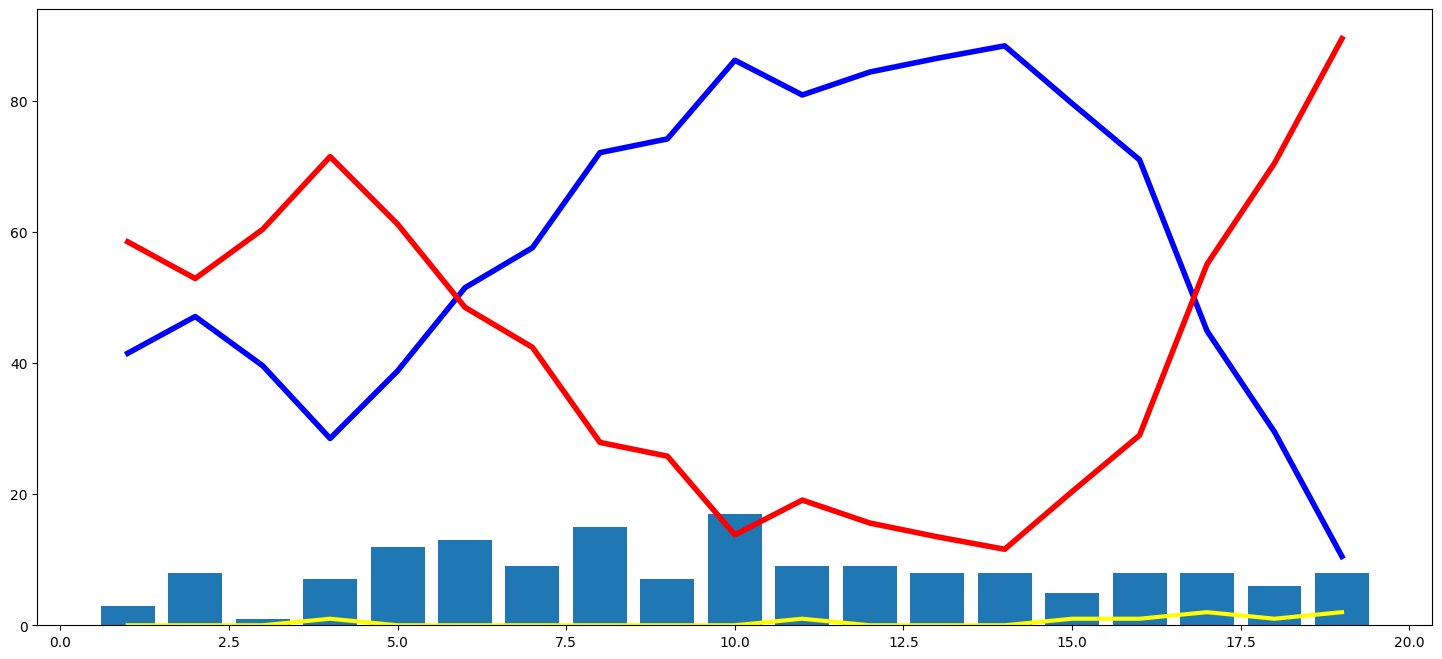

In [131]:
plt.figure(figsize=(18,8))
plt.plot(temp_df["end_of_over"],temp_df["wickets_in_over"],color="yellow",linewidth=3)
plt.plot(temp_df["end_of_over"],temp_df["win"],color="blue",linewidth=4)
plt.plot(temp_df["end_of_over"],temp_df["lose"],color="red",linewidth=4)
plt.bar(temp_df["end_of_over"],temp_df["runs_after_over"])




In [132]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Punjab Kings',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals',
 'Gujrat Titans',
 'Lucknow Super Gaints']

In [133]:
delivery_df["city"].unique()

array(['Hyderabad', 'Pune', 'Rajkot', 'Indore', 'Bangalore', 'Mumbai',
       'Kolkata', 'Delhi', 'Chandigarh', 'Kanpur', 'Jaipur', 'Chennai',
       'Cape Town', 'Port Elizabeth', 'Durban', 'Centurion',
       'East London', 'Johannesburg', 'Kimberley', 'Bloemfontein',
       'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala', 'Visakhapatnam',
       'Raipur', 'Ranchi', 'Abu Dhabi', 'Sharjah', nan, 'Mohali',
       'Bengaluru'], dtype=object)

In [137]:
import pickle
pickle.dump(pipe2,open("pipe.pkl","wb"))

In [138]:
import sklearn
print(sklearn.__version__)

1.6.1
